# Preparando o ambiente

In [1]:
# instalações
!pip install -q ultraplot cartopy salem rasterio pyproj geopandas

# importa bibliotecas
import ultraplot as uplt
import cartopy.crs as ccrs
import cartopy.io.shapereader as shpreader
import pandas as pd
from datetime import timedelta, datetime
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
import os
import imageio
import glob
import calendar
import pandas as pd
import glob
import numpy as np
import xarray as xr
import time
import salem
import warnings
warnings.filterwarnings("ignore")

# monta o drive
from google.colab import drive
drive.mount('/content/drive')

# diretório raiz
dir = '/content/drive/MyDrive/2-PESQUISA/artigo_queimadas_vanessa_2025/0_round1_revisoes'

# diretório de entrada
dir_input = f'{dir}/output/04_netcdf_focos_por_mes'

# diretório de saída
dir_output = f'{dir}/output'

# cria pasta de saída
os.makedirs(dir_output, exist_ok=True)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 49.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 83.5/83.5 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 54.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 32.3 MB/s eta 0:00:00
Mounted at /content/drive


# Calcula anomalia de focos de calor por mês

In [2]:
%%time
# limites do estado de SP
lonmin_sp, lonmax_sp, latmin_sp, latmax_sp = -53.3, -43.9, -25.4, -19.7

# leitura do shapefile de SP
shapefile_sp = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp')

# leitura do shapefile do Brasil
shapefile_brasil = salem.read_shapefile('https://github.com/evmpython/shapefile/raw/main/brasil/BRAZIL.shp')

# lista dos arquivos
files = sorted(glob.glob(f'{dir_input}/focos_mensal_brasil_*.nc')) # focos_mensal_brasil_AQUA_2003-01.nc

# leitura dos arquivos por ano
focos_por_mes = xr.open_mfdataset(files, concat_dim='time', combine='nested')

# coloca "NaN" onde os "focos=0"
condicao = focos_por_mes['focos'][:,:,:] == 0
focos_por_mes['focos'][:,:,:] = np.where(condicao, np.nan, focos_por_mes['focos'][:,:,:])

## EXEMPLO:
#udel_air_AS_clima = udel_air_AS.groupby('time.month').mean('time')
#anom_air_AS = udel_air_AS.groupby('time.month') - udel_air_AS_clima
# calculando a CLIMATOLOGIA: 2003-2023
climatologia = focos_por_mes.groupby('time.month').mean(dim='time')

# calculando a ANOMALIA
anomalia = focos_por_mes.groupby('time.month') - climatologia

# recorta o dado para região
climatologia = climatologia.salem.roi(shape=shapefile_brasil)
anomalia = anomalia.salem.roi(shape=shapefile_brasil)

# recorta o dado para o estado de SP
anomalia_sp = anomalia.salem.roi(shape=shapefile_sp)
climatologia_sp = climatologia.salem.roi(shape=shapefile_sp)

CPU times: user 10.7 s, sys: 1.48 s, total: 12.2 s
Wall time: 35.9 s


In [5]:
# mostra a CLIMATOLOGIA
climatologia_sp

<xarray.Dataset> Size: 4MB
Dimensions:  (month: 12, lat: 210, lon: 210)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
Data variables:
    focos    (month, lat, lon) float64 4MB dask.array<chunksize=(1, 210, 210), meta=np.ndarray>
Attributes:
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs

In [6]:
# mostra a ANOMALIA
anomalia_sp

<xarray.Dataset> Size: 93MB
Dimensions:  (time: 264, lat: 210, lon: 210)
Coordinates:
  * time     (time) datetime64[ns] 2kB 2003-01-01 2003-02-01 ... 2024-12-01
  * lat      (lat) float64 2kB 7.0 6.8 6.6 6.4 6.2 ... -34.2 -34.4 -34.6 -34.8
  * lon      (lon) float64 2kB -75.0 -74.8 -74.6 -74.4 ... -33.6 -33.4 -33.2
    month    (time) int64 2kB 1 2 3 4 5 6 7 8 9 10 11 ... 3 4 5 6 7 8 9 10 11 12
Data variables:
    focos    (time, lat, lon) float64 93MB dask.array<chunksize=(1, 210, 210), meta=np.ndarray>
Attributes:
    pyproj_srs:  +proj=longlat +datum=WGS84 +no_defs

# Leitura dos dados das estações de medição de qualidade do ar

In [7]:
# leitura dos dados da estações de medição de qualidade do ar
df_estacoes = pd.read_excel(f'{dir}/input/Informações-estações.xlsx')
df_estacoes.iloc[6,0] = 'Campinas'
df_estacoes.iloc[10,0] = 'Cubatão'
df_estacoes.iloc[16,0] = 'Guarulhos'
df_estacoes.iloc[17,0] = 'Santo André'
#df_estacoes = df_estacoes.drop(14) # São Caetano do Sul não tem dados
df_estacoes.iloc[14,4] = '-99.9'
df_estacoes.iloc[14,5] = '-99.9'
df_estacoes
# 5 melhores estações

# eliminar a linha de são caetano do sul
df_estacoes = df_estacoes.drop(index=14)
df_estacoes

,Estação,Código,Lat,Lon,PM10 (%),O3 (%)
0,Presidente Prudente,114,-22.11990,-51.40880,88.26,90.28
1,Araçatuba,107,-21.18680,-50.43930,86.71,85.62
2,São José do Rio Preto,116,-20.78470,-49.39830,86.85,82.51
3,Ribeirão Preto,288,-21.17708,-47.81900,76.71,69.58
4,Jaú,110,-22.29862,-48.56746,91.18,84.70
5,Jundiaí,109,-23.19200,-46.89710,92.07,89.68
6,Campinas,276,-22.87462,-47.05897,87.62,83.21
7,Paulínia,117,-22.77232,-47.15484,88.12,84.65
8,São José dos Campos,88,-23.18789,-45.87120,91.45,88.97
9,Guaratinguetá,289,-22.80192,-45.19112,63.40,82.89


# Plota mapa de anomalia de focos de calor para SP e dados das estações de medição de qualidade do ar

Processando ===>>> 0-2024-01
Processando ===>>> 1-2024-02
Processando ===>>> 2-2024-03
Processando ===>>> 3-2024-04
Processando ===>>> 4-2024-05
Processando ===>>> 5-2024-06
Processando ===>>> 6-2024-07
Processando ===>>> 7-2024-08
Processando ===>>> 8-2024-09
Processando ===>>> 9-2024-10
Processando ===>>> 10-2024-11
Processando ===>>> 11-2024-12


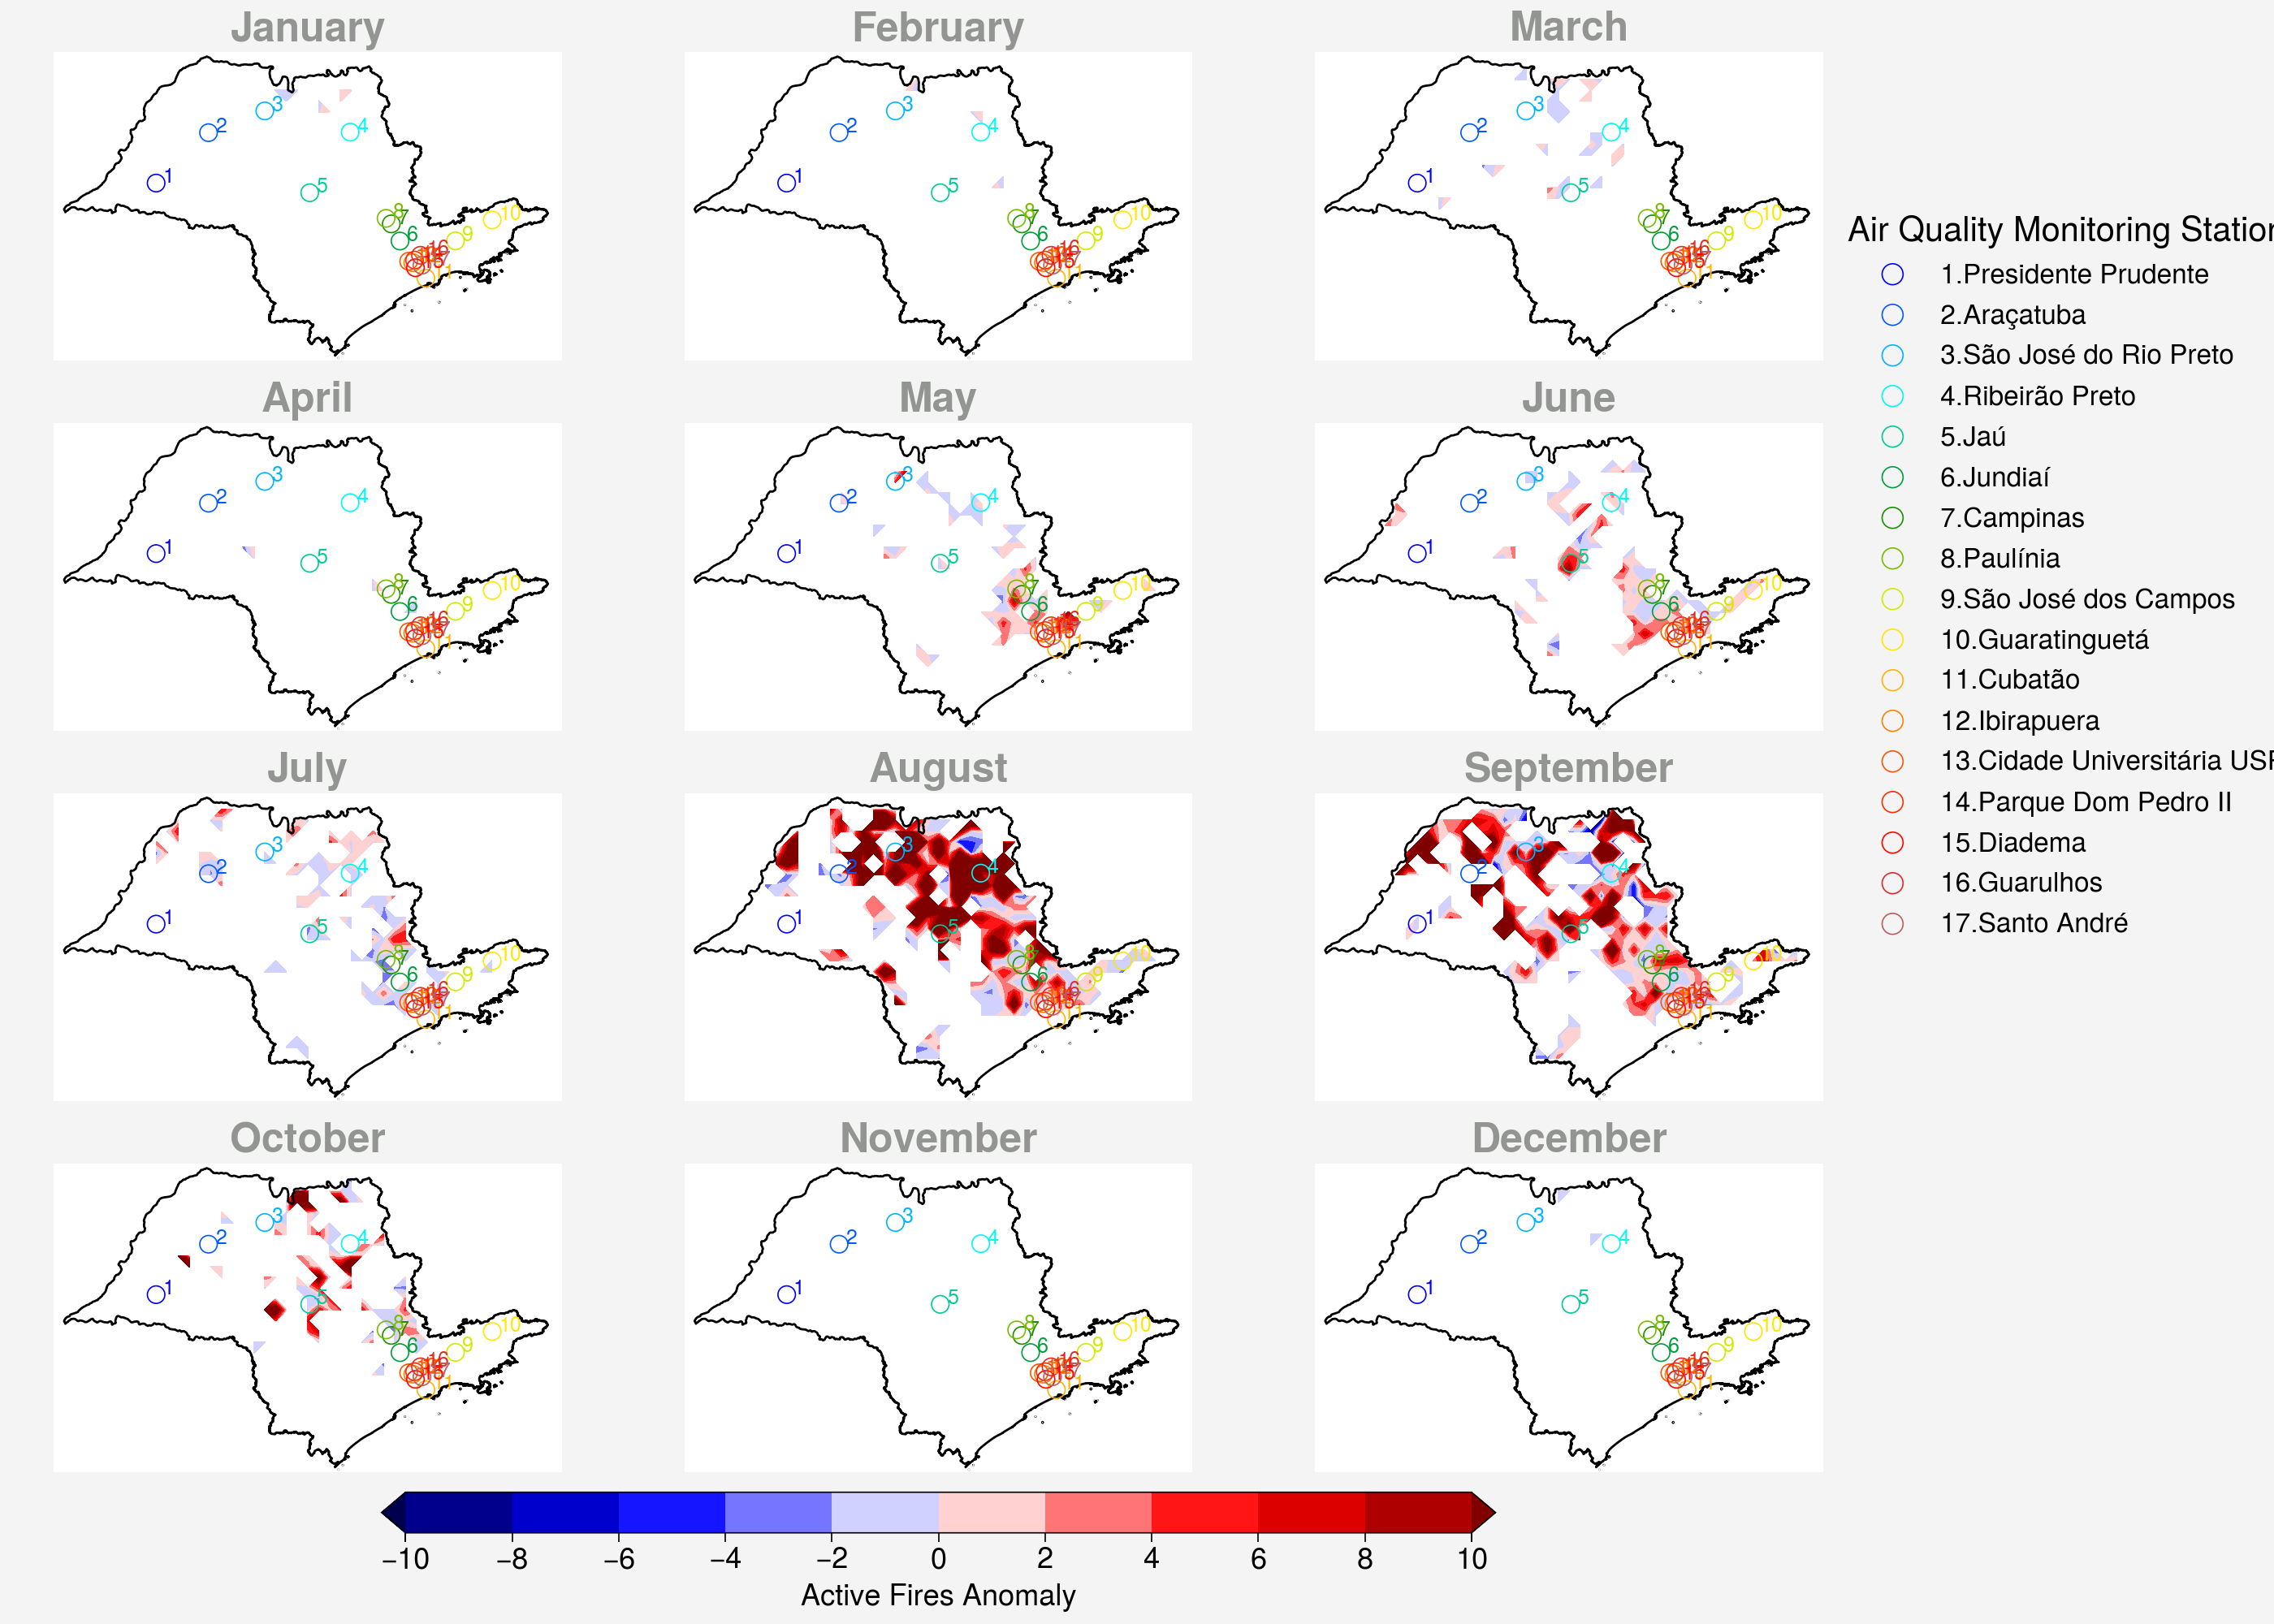

In [4]:
# meses
#meses = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
meses = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December']

# cria a moldura da figura
fig, ax = uplt.subplots(figsize=(14,10),
                        nrows=4, ncols=3,
                        tight=True,
                        proj='pcarree',
                        sharex=True, sharey=True)

# formatação dos eixos
ax.format(coast=False, borders=False, innerborders=False,
          labels=False, latlines=5, lonlines=10,
          latlim=(latmin_sp, latmax_sp), lonlim=(lonmin_sp, lonmax_sp),
          small='20px', large='25px',
          linewidth=0, grid=False)

#--------------------------------------------------------------------#
cores_18 = ['#0000FF',  # Azul puro
            '#0033FF',  # Azul médio
            '#0066FF',  # Azul claro
            '#0099FF',  # Azul céu
            '#00CCFF',  # Azul cyan

            '#00FFFF',  # Cyan
            '#00FFCC',  # Cyan esverdeado

            '#00FF99',  # Verde-água
            '#00FF66',  # Verde claro
            '#00FF33',  # Verde limão
            '#00FF00',  # Verde puro
            '#33FF00',  # Verde-amarelado

            '#66FF00',  # Lima
            '#99FF00',  # Amarelo-esverdeado
            '#CCFF00',  # Amarelo claro
            '#FFFF00',  # Amarelo puro

            '#FF9900',  # Laranja
            '#FF3300',  # Vermelho-alaranjado
            '#FF0000'   # Vermelho puro
            ]

cores_18 = ['#0000FF', '#0044FF', '#0088FF', '#00BBFF', '#00FFFF',
            '#00FFBB', '#00FF77', '#00FF33', '#33FF00', '#77FF00',
            '#BBFF00', '#FFFF00', '#FFBB00', '#FF7700', '#FF3300',
            '#FF1100', '#FF0055', '#FF0000']

cores_18 = ['#0000FF', '#0044FF', '#0088FF', '#00BBFF', '#00FFFF',
            '#00FFBB', '#00FF77', '#00FF33', '#77FF00',
            '#BBFF00', '#FFFF00', '#FFBB00', '#FF7700', '#FF3300',
            '#FF1100', '#FF0055', '#FF0000']

from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list('azul_vermelho', ['blue', 'cyan', 'green', 'yellow', 'orange', 'red', 'gray'], N=18)
cores_18 = [cmap(i) for i in range(18)]  # Cores no formato RGBA

# estações
for j in range(len(df_estacoes)):

    # extrai informações da estação
    codigo = df_estacoes['Código'].iloc[j]
    municipio = df_estacoes['Estação'].iloc[j]
    lat = df_estacoes['Lat'].iloc[j]
    lon = df_estacoes['Lon'].iloc[j]
    pm10 = df_estacoes['PM10 (%)'].iloc[j]
    o3 = df_estacoes['O3 (%)'].iloc[j]

    # plota o símbolo da estação
    ax.scatter(lon,
               lat,
               transform=ccrs.PlateCarree(),
               marker='o',
               s=60,
               facecolors='none',
               edgecolors=cores_18[j],
               zorder=2,
               label=f' {j+1}.{municipio}')
    ax.text(lon+0.12, lat, j+1, color=cores_18[j], s=10, transform=ccrs.PlateCarree(), zorder=4)

# legenda
ax[5].legend(title='Air Quality Monitoring Stations',
             title_fontsize=15,
             loc='right',
             ncols=1,
             frameon=False,
             prop={'size': 12.},
             markerscale=1.2)
#--------------------------------------------------------------------#

# loop dos meses de 2024
i=0
for data in pd.date_range('20240101', '20241231', freq='1M'):

    # estrai ano e mês
    ano = data.strftime('%Y')
    mes = data.strftime('%m')

    print('Processando ===>>>', f'{i}-{ano}-{mes}')


    if i==0:

        # plota figura
        map1 = ax[i].contourf(anomalia_sp['lon'],
                              anomalia_sp['lat'],
                              anomalia_sp['focos'].loc[f'{ano}-{mes}-01'],
                              cmap='seismic',
                              vmin=-10, vmax=10,
                              levels=uplt.arange(-10, 10, 2),
                              extend='both')

    else:
        ax[i].contourf(anomalia_sp['lon'],
                       anomalia_sp['lat'],
                       anomalia_sp['focos'].loc[f'{ano}-{mes}-01'],
                       cmap='seismic',
                       vmin=-10, vmax=10,
                       levels=uplt.arange(-10, 10, 2),
                       extend='both')

    # plota titulo de cada figura
    mesint = int(mes)
    ax[i].format(title=f'{meses[mesint-1]}', labels = False, titleloc='c', titlecolor='grey', titleweight='bold', small='5px')

    # shapefile
    shapefile = list(shpreader.Reader('https://github.com/evmpython/shapefile/raw/main/UFs/SP/SP_UF_2019.shp').geometries())
    ax[i].add_geometries(shapefile, ccrs.PlateCarree(), edgecolor='black', facecolor='none', linewidth=1.0)

    i+=1

# plota barra de cores da figura
fig.colorbar(map1,
             loc='b',
             label='Active Fires Anomaly',
             ticks=2,
             ticklabelsize=13,
             labelsize=13,
             length=0.60,
             width=0.25)

# salva figura
fig.savefig(f'{dir_output}/Fig_5_anomalia_focos_mensal_2024_sp_20km.jpg', transparent=True, dpi=300, bbox_inches="tight")